# Notebook 01 - Dataset Exploration

**Goal:** Understand the structure of the `uk_password` dataset before running any quality checks.

---

## Dataset Structure

```
uk_password/
└── UK/
    └── {person_id}/
        └── L{1-4}/B{1-4}/A{1-3}/
            └── P_UK_{id}_L{l}_B{b}_A{a}_D{d}.jpg
```

| Variable | Options | Meaning |
|---|---|---|
| **L** | 1–4 | Lighting conditions |
| **B** | 1–4 | Background types |
| **A** | 1–3 | Camera angles |
| **D** | 1–2 | Distance from camera |

**Expected: 5 people × 96 images = 480 total**

In [5]:
import os
os.chdir('..')  # go up one level from notebooks/ to project root
print("Now running from:", os.getcwd())

Now running from: c:\kyc-document-quality


In [6]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from collections import Counter
from src.parser import parse_filename
from src.config import DATASET_ROOT, IMAGE_EXTENSIONS

## 1. Count All Images

In [7]:
all_images = [
    p for p in Path(DATASET_ROOT).rglob('*')
    if p.suffix.lower() in IMAGE_EXTENSIONS
]

print(f'Total images found: {len(all_images)}')
print(f'Example path: {all_images[0]}')

Total images found: 480
Example path: uk_password\UK\427583910\L1\B1\A1\P_UK_427583910_L1_B1_A1_D1.jpg


## 2. Count Images per Person

In [8]:
person_counts = Counter()
for p in all_images:
    meta = parse_filename(p.name)
    person_counts[meta['person_id']] += 1

print('Images per person:')
for person_id, count in sorted(person_counts.items()):
    print(f'  Person {person_id}: {count} images')

Images per person:
  Person 427583910: 96 images
  Person 487239561: 96 images
  Person 489153026: 92 images
  Person 489352716: 96 images
  Person 748392615: 96 images
  Person unknown: 4 images


## 3. Distribution of Variables (L, B, A, D)

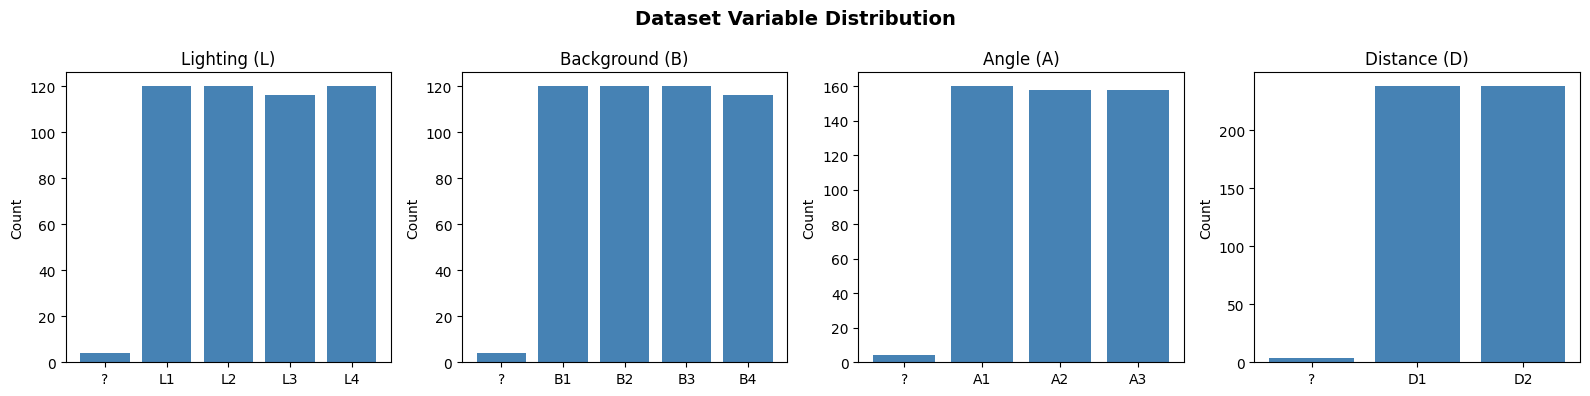

In [9]:
L_counts = Counter()
B_counts = Counter()
A_counts = Counter()
D_counts = Counter()

for p in all_images:
    meta = parse_filename(p.name)
    L_counts[meta['lighting']] += 1
    B_counts[meta['background']] += 1
    A_counts[meta['angle']] += 1
    D_counts[meta['distance']] += 1

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Dataset Variable Distribution', fontsize=14, fontweight='bold')

for ax, (counts, title) in zip(axes, [
    (L_counts, 'Lighting (L)'),
    (B_counts, 'Background (B)'),
    (A_counts, 'Angle (A)'),
    (D_counts, 'Distance (D)'),
]):
    keys   = sorted(counts.keys())
    values = [counts[k] for k in keys]
    ax.bar(keys, values, color='steelblue')
    ax.set_title(title)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Preview Sample Images

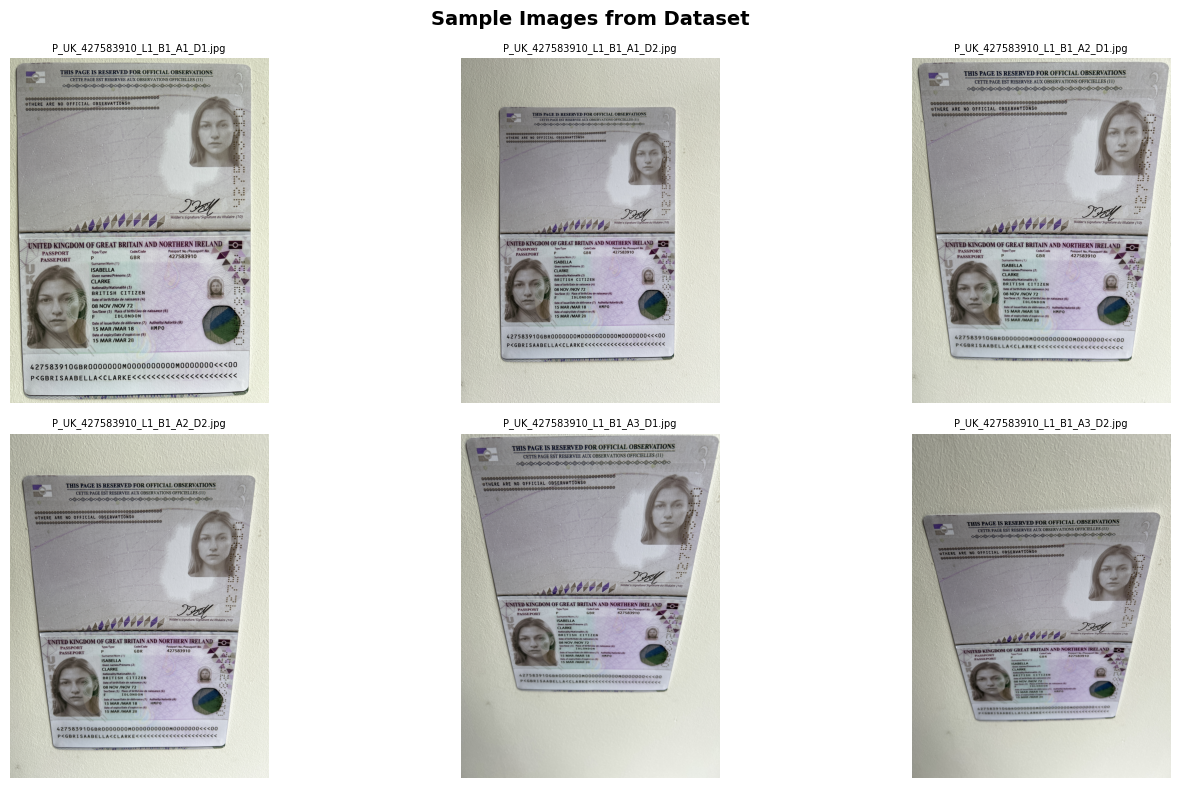

In [10]:
# Show first 6 images from the dataset
sample = all_images[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Sample Images from Dataset', fontsize=14, fontweight='bold')

for ax, img_path in zip(axes.flatten(), sample):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(img_path.name, fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()